# Marketing Campaign & ROI EDA
Synthetic portfolio data, 2025, INR. This notebook reads the cleaned pipeline output. Run `python src/analyze.py` first.

In [1]:
from pathlib import Path
import pandas as pd
def display(x): print(x.to_string() if hasattr(x, "to_string") else x)
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
df = pd.read_csv(ROOT/'data/clean_campaigns.csv', parse_dates=['date'])
display(df.head())
print('Records:', len(df))

        date         campaign_id channel     audience     spend  impressions  clicks  acquisitions    revenue  contribution_profit    month
0 2025-01-01  Search_Prospecting  Search  Prospecting   4605.20         5249     179            11   25085.48             13797.01  2025-01
1 2025-01-01    Search_Retention  Search    Retention  14350.98        14835     507            28   43429.51             23886.23  2025-01
2 2025-01-01  Social_Prospecting  Social  Prospecting   7834.04        16016     358             8   17715.98              9743.79  2025-01
3 2025-01-01    Social_Retention  Social    Retention   6088.70        15586     335            10   16234.32              8928.88  2025-01
4 2025-01-01   Email_Prospecting   Email  Prospecting   3752.09        14407    1013            87  163609.06             89984.98  2025-01
Records: 3635


In [2]:
display(df.describe())
print('Missing values:', df.isna().sum().to_dict())
assert not df.duplicated(['date','campaign_id']).any()
assert (df.clicks <= df.impressions).all()
assert (df.acquisitions <= df.clicks).all()

                                date         spend   impressions       clicks  acquisitions        revenue  contribution_profit
count                           3635   3635.000000   3635.000000  3635.000000   3635.000000    3635.000000          3635.000000
mean   2025-07-02 17:35:44.154057984   4937.128399  10974.426685   359.258322     22.155708   43325.300825         23828.915620
min              2025-01-01 00:00:00    453.020000   4005.000000    29.000000      0.000000       0.000000             0.000000
25%              2025-04-03 00:00:00   2227.275000   7393.000000   152.000000      4.000000    8529.650000          4691.305000
50%              2025-07-03 00:00:00   3974.870000  10999.000000   293.000000     12.000000   24347.720000         13391.250000
75%              2025-10-02 00:00:00   6206.010000  14520.500000   456.000000     28.000000   54930.865000         30211.975000
max              2025-12-31 00:00:00  19996.020000  17999.000000  1303.000000    138.000000  318604.5200

In [3]:
channel = pd.read_csv(ROOT/'outputs/channel_summary.csv')
display(channel.sort_values('roi', ascending=False))
monthly = pd.read_csv(ROOT/'outputs/monthly_summary.csv')
monthly['revenue_mom'] = monthly.revenue.pct_change()
display(monthly[['month','spend','revenue','revenue_mom','roi']])

     channel       spend  impressions  clicks  acquisitions      revenue  contribution_profit  net_contribution       ctr        cpc  conversion_rate         cpa       roas        roi
2      Email  2265933.47      8084833  566537         46557  90821370.68          49951754.01       47685820.54  0.070074   3.999621         0.082178   48.670092  40.081217  21.044669
0  Affiliate  3178033.09      7888107  212632         10539  20575514.44          11316532.99        8138499.90  0.026956  14.946166         0.049565  301.549776   6.474292   2.560861
3     Search  7714553.40      7872142  275359         16799  33066480.74          18186564.60       10472011.20  0.034979  28.016347         0.061008  459.226942   4.286247   1.357436
4     Social  3576219.45      8077909  179624          5287  10357066.05           5696386.45        2120167.00  0.022236  19.909475         0.029434  676.417524   2.896094   0.592851
1    Display  1211722.32      7969050   71752          1354   2667036.59        

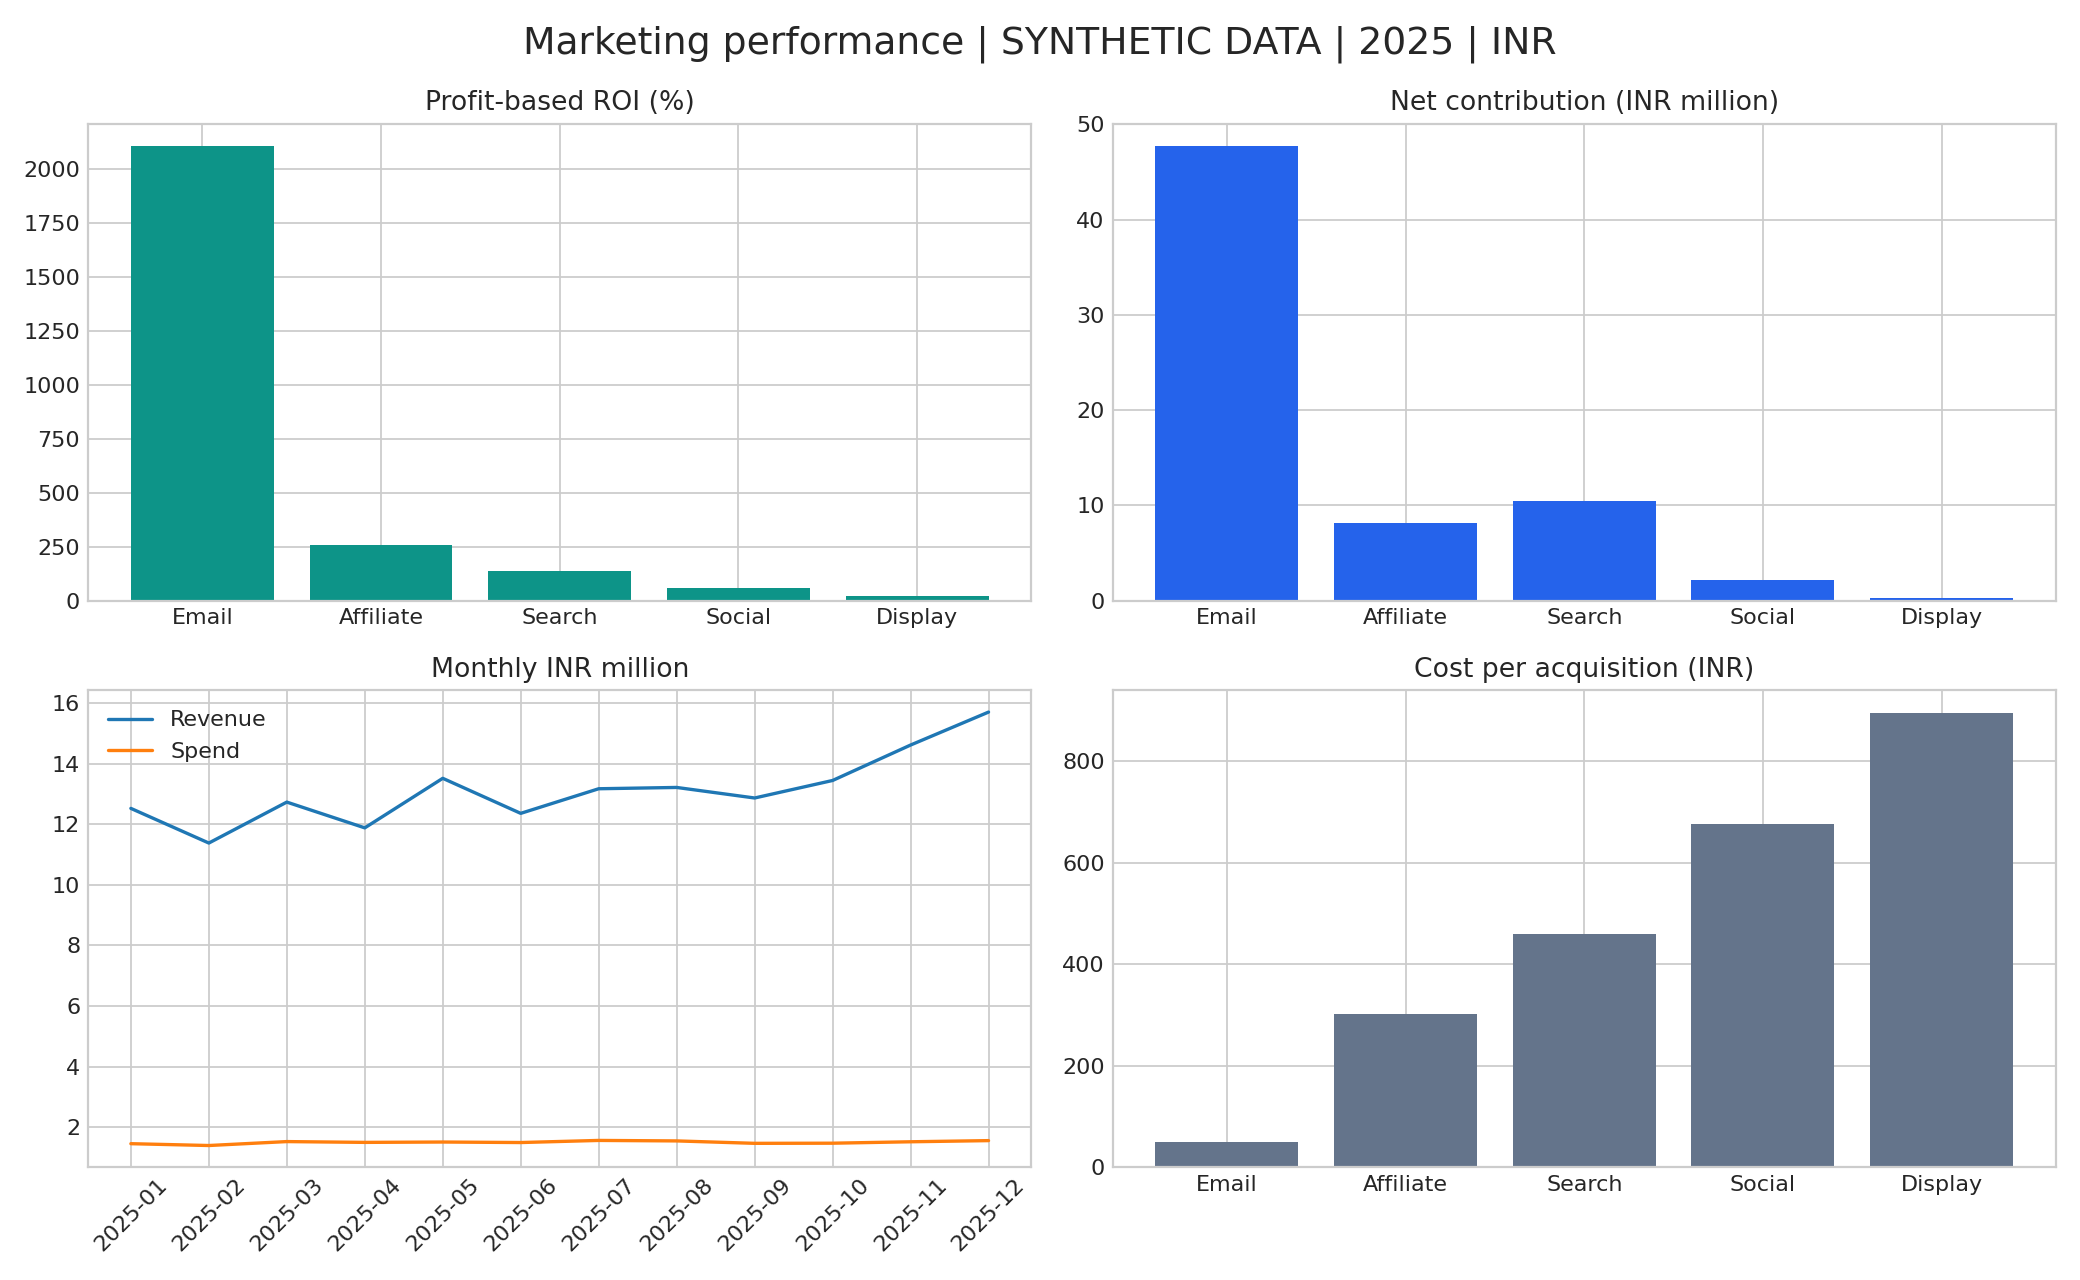

In [4]:
from IPython.display import display, Image
display(Image(filename=str(ROOT/'outputs/dashboard.png')))

## Interpretation
Email has the highest observed ROI in this simulation. Its lower CPC and stronger conversion assumptions are designed into the generator. Ratios use aggregated sums. Last-click attribution cannot establish incrementality; a capped holdout test is the proposed next step. Read the final report for all exclusions and limitations.